# Behavioral Cloning - Supervised MSE

Trains an MLP policy via supervised imitation learning on human demonstrations for the `OpenElectricKettleLid` task.

> **Runtime:** `T4 GPU`

## 1. Setup

In [ ]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else 'No GPU :(')

Fri Apr  3 18:20:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
GITHUB_TOKEN = ''
REPO    = 'sergio-contente/RoboCasa-Project'
BRANCH  = 'b313'
WORKDIR = '/content/RoboCasa-Project'

import os

clone_url = (
    f'https://{GITHUB_TOKEN}@github.com/{REPO}.git'
    if GITHUB_TOKEN else
    f'https://github.com/{REPO}.git'
)

if not os.path.isdir(WORKDIR):
    subprocess.run(
        ['git', 'clone', '--recurse-submodules', '-b', BRANCH, clone_url, WORKDIR],
        check=True
    )
else:
    print(f'{WORKDIR} exists — pulling latest.')
    subprocess.run(['git', '-C', WORKDIR, 'pull'], check=True)
    subprocess.run(
        ['git', '-C', WORKDIR, 'submodule', 'update', '--init', '--recursive'],
        check=True
    )

log = subprocess.run(['git', '-C', WORKDIR, 'log', '--oneline', '-3'],
                     capture_output=True, text=True)
print(log.stdout)

79959eb ✨
0b0ddaa 🚧  BC
de57827 ✨



In [ ]:
import sys
WORKDIR = '/content/RoboCasa-Project'

pip = [sys.executable, '-m', 'pip', 'install']

print('Installing robosuite...')
subprocess.run([*pip, '-e', f'{WORKDIR}/deps/robosuite', '-q'], check=True)

print('Installing robocasa...')
subprocess.run([*pip, '-e', f'{WORKDIR}/deps/robocasa', '-q'], check=True)

print('Installing stable-baselines3 + utilities...')
subprocess.run([*pip, 'stable-baselines3', 'pyarrow', '-q'], check=True)

print('Setting up robocasa macros...')
subprocess.run(
    [sys.executable, '-m', 'robocasa.scripts.setup_macros'],
    input='y\n', text=True, cwd=WORKDIR,
)

print('Downloading kitchen assets...')
subprocess.run(
    [sys.executable, '-m', 'robocasa.scripts.download_kitchen_assets'],
    input='y\n', text=True, cwd=WORKDIR,
)

print('Done — restarting kernel...')

Installing robosuite...
Installing robocasa...
Installing stable-baselines3 + utilities...
Setting up robocasa macros...
Done — restarting kernel...


In [ ]:
# Restart kernel so installs are active. Continue after restart.
#import os; os.kill(os.getpid(), 9)

In [ ]:
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
os.makedirs(DATASET_BASE, exist_ok=True)

# Write DATASET_BASE_PATH into robocasa before first import
import robocasa
with open(os.path.join(robocasa.__path__[0], 'macros_private.py'), 'w') as f:
    f.write(f'DATASET_BASE_PATH = "{DATASET_BASE}"\n')
print(f'DATASET_BASE_PATH = {DATASET_BASE}')

DATASET_PATH = (
    f'{DATASET_BASE}/v1.0/pretrain/atomic/OpenElectricKettleLid/20250820/lerobot'
)

if os.path.isdir(os.path.join(DATASET_PATH, 'data')):
    from pathlib import Path
    n = len(list(Path(DATASET_PATH).glob('data/*/episode_*.parquet')))
    print(f'Dataset already present - {n} episodes found.')
else:
    print('Downloading dataset (pretrain / human, ~200 MB)...')
    result = subprocess.run(
        [
            'python', '-m', 'robocasa.scripts.download_datasets',
            '--tasks',  'OpenElectricKettleLid',
            '--split',  'pretrain',
            '--source', 'human',
        ],
        input='y\n',
        text=True,
        capture_output=False,
        env={**os.environ, 'ROBOCASA_DATASET_BASE_PATH': DATASET_BASE},
    )
    if result.returncode != 0:
        raise RuntimeError('Download failed - check output above.')
    print('Download complete.')

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /content/RoboCasa-Project/deps/robosuite/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


DATASET_BASE_PATH = /content/datasets
Download complete.


In [ ]:
from pathlib import Path
ds = Path(DATASET_PATH)
print('Dataset structure:')
for d in ['data', 'extras', 'meta']:
    print(f'  {d}/  {"✓" if (ds/d).is_dir() else "✗ missing"}')
episodes = list(ds.glob('data/*/episode_*.parquet'))
print(f'  episodes: {len(episodes)}')
print(f'  modality.json: {"✓" if (ds/"meta"/"modality.json").exists() else "x (bundled fallback OK)"}')

Dataset structure:
  data/  ✓
  extras/  ✓
  meta/  ✓
  episodes: 110
  modality.json: ✓


In [ ]:
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
OUTPUT_DIR   = f'{WORKDIR}/results'

os.chdir(WORKDIR)
if WORKDIR not in sys.path:
    sys.path.insert(0, WORKDIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

import torch
print(f'Working dir  : {os.getcwd()}')
print(f'Dataset base : {DATASET_BASE}')
print(f'Results dir  : {OUTPUT_DIR}')
print(f'Device       : {"cuda" if torch.cuda.is_available() else "cpu"}')

Working dir  : /content/RoboCasa-Project
Dataset base : /content/datasets
Results dir  : /content/RoboCasa-Project/results
Device       : cuda


In [ ]:
N_DEMO_EPISODES = 50      # expert episodes to load (max ~110 available)
N_EPOCHS        = 100     # supervised training epochs
BATCH_SIZE      = 256
LEARNING_RATE   = 3e-4
HIDDEN_DIM      = 256
N_EVAL_EPISODES = 20      # rollout episodes after training
DATASET_SPLIT   = 'pretrain'

## 2. Train BC

In [ ]:
import train_bc
import importlib; importlib.reload(train_bc)

train_bc.main([
    '--episodes',   str(N_DEMO_EPISODES),
    '--epochs',     str(N_EPOCHS),
    '--batch-size', str(BATCH_SIZE),
    '--lr',         str(LEARNING_RATE),
    '--hidden-dim', str(HIDDEN_DIM),
    '--eval-ep',    str(N_EVAL_EPISODES),
    '--split',      DATASET_SPLIT,
    '--dataset-root', DATASET_BASE,
    '--output',     OUTPUT_DIR,
])

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers

In [ ]:
import json

out = Path(OUTPUT_DIR)

eval_file = out / 'bc_eval.json'
if not eval_file.exists():
    print('bc_eval.json not found.')
else:
    metrics = json.loads(eval_file.read_text())
    print('BC Evaluation Results')
    print('─' * 38)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f'  {k:<28}: {v:.4f}')
        else:
            print(f'  {k:<28}: {v}')

BC Evaluation Results
──────────────────────────────────────
  success_rate                : 0.0000
  avg_lid_progress            : 0.0000
  std_lid_progress            : 0.0000
  avg_reward                  : 0.0000
  avg_episode_length          : 500.0000
  n_episodes                  : 20


## 3. Plots

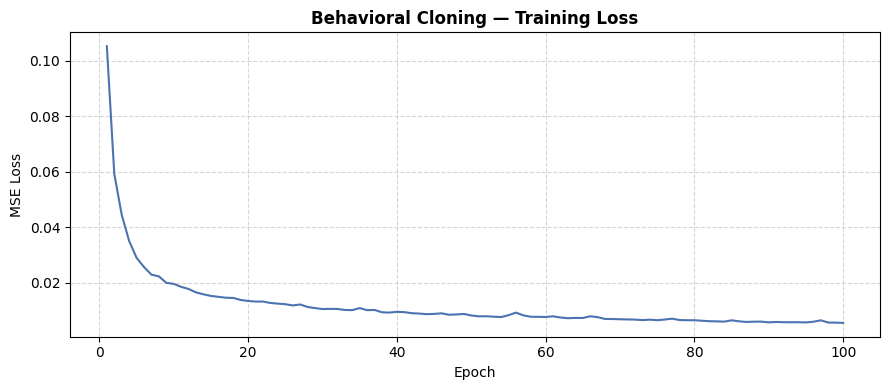

Initial loss : 0.105173
Final loss   : 0.005651
Reduction    : 94.6%


In [ ]:
import matplotlib.pyplot as plt

losses_file = out / 'bc_losses.json'
if not losses_file.exists():
    print('bc_losses.json not found.')
else:
    losses = json.loads(losses_file.read_text())['losses']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(losses) + 1), losses, color='#4C72B0', linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Behavioral Cloning — Training Loss', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(out / 'bc_loss_curve.png', dpi=150)
    plt.show()
    print(f'Initial loss : {losses[0]:.6f}')
    print(f'Final loss   : {losses[-1]:.6f}')
    print(f'Reduction    : {(1 - losses[-1]/losses[0])*100:.1f}%')

In [ ]:
import numpy as np
from common import load_bc_checkpoint
from gym_wrapper import make_env

# Load trained policy
policy = load_bc_checkpoint(str(out / 'bc_model.pt'))
eval_env = make_env(reward_mode='dense', seed=99)

successes, lid_progs, rewards, lengths = [], [], [], []
all_timestep_rewards = []

for ep in range(N_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False
    ep_r, ep_len = 0.0, 0
    ep_step_rewards = []
    info = {}

    while not done:
        action = policy.predict_numpy(obs)
        obs, r, terminated, truncated, info = eval_env.step(action)
        ep_r += float(r)
        ep_len += 1
        ep_step_rewards.append(float(r))
        done = terminated or truncated

    successes.append(int(info.get('success', False)))
    lid_progs.append(float(info.get('lid_progress', 0.0)))
    rewards.append(ep_r)
    lengths.append(ep_len)
    all_timestep_rewards.append(ep_step_rewards)
    print(f'  Episode {ep+1:>2}/{N_EVAL_EPISODES}  '
          f'len={ep_len:<4}  reward={ep_r:.5f}  '
          f'lid={info.get("lid_progress", 0.0):.3f}')

eval_env.close()

eval_metrics = {
    'success_rate':       sum(successes) / N_EVAL_EPISODES,
    'avg_lid_progress':   float(np.mean(lid_progs)),
    'std_lid_progress':   float(np.std(lid_progs)),
    'avg_reward':         float(np.mean(rewards)),
    'std_reward':         float(np.std(rewards)),
    'avg_episode_length': float(np.mean(lengths)),
    'n_episodes':         N_EVAL_EPISODES,
}

(out / 'bc_eval_curves.json').write_text(_json.dumps({
    'metrics': eval_metrics,
    'timestep_rewards': all_timestep_rewards,
    'lid_progs': lid_progs,
    'episode_rewards': rewards,
    'episode_lengths': lengths,
}, indent=2))

print()
print('BC Evaluation Results (re-run)')
print('─' * 38)
for k, v in eval_metrics.items():
    if isinstance(v, float):
        print(f'  {k:<28}: {v:.4f}')
    else:
        print(f'  {k:<28}: {v}')
print(f'\nSaved → {out / "bc_eval_curves.json"}')

[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


  Episode  1/20  len=500   reward=0.00000  lid=0.000
  Episode  2/20  len=500   reward=0.00000  lid=0.000
  Episode  3/20  len=500   reward=0.00000  lid=0.000
  Episode  4/20  len=500   reward=0.00000  lid=0.000
  Episode  5/20  len=500   reward=0.00000  lid=0.000
  Episode  6/20  len=500   reward=0.00000  lid=0.000
  Episode  7/20  len=500   reward=0.00000  lid=0.000
  Episode  8/20  len=500   reward=0.00000  lid=0.000
  Episode  9/20  len=500   reward=0.00000  lid=0.000
  Episode 10/20  len=500   reward=0.00000  lid=0.000
  Episode 11/20  len=500   reward=0.00000  lid=0.000
  Episode 12/20  len=500   reward=0.00000  lid=0.000
  Episode 13/20  len=500   reward=0.00000  lid=0.000
  Episode 14/20  len=500   reward=0.00000  lid=0.000
  Episode 15/20  len=500   reward=0.00001  lid=0.000
  Episode 16/20  len=500   reward=0.00000  lid=0.000
  Episode 17/20  len=500   reward=0.00002  lid=0.000
  Episode 18/20  len=500   reward=0.00000  lid=0.000
  Episode 19/20  len=500   reward=0.00000  lid

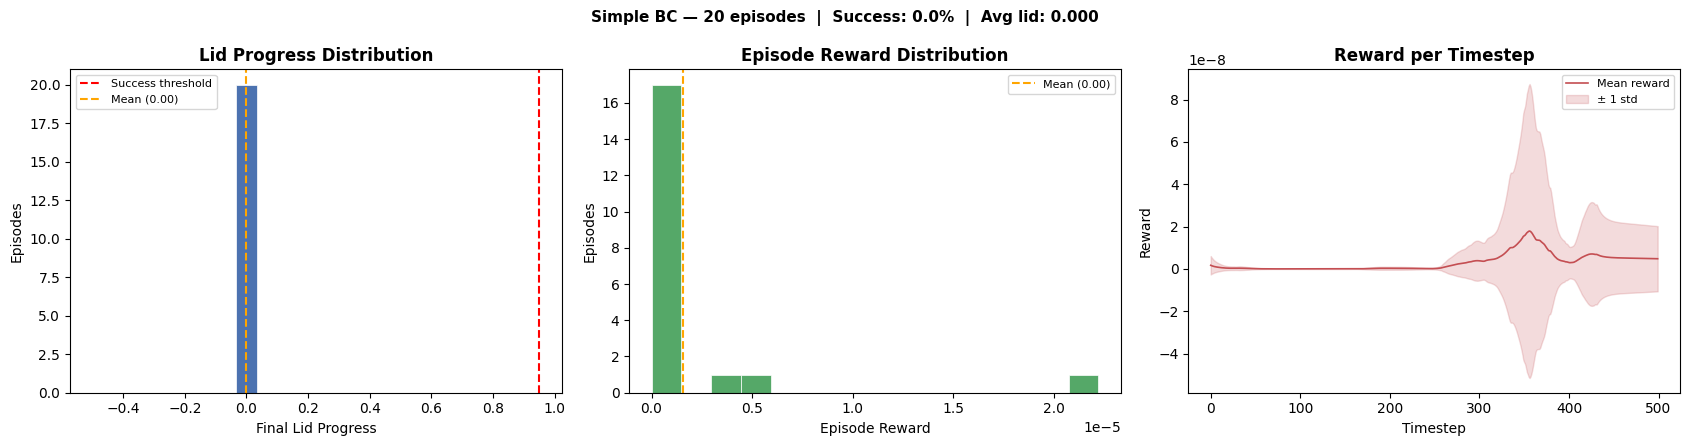

Saved → /content/RoboCasa-Project/results/bc_eval_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Lid progress histogram
axes[0].hist(lid_progs, bins=15, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0.95, color='red', linestyle='--', linewidth=1.5,
                label='Success threshold')
axes[0].axvline(x=float(np.mean(lid_progs)), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({np.mean(lid_progs):.2f})')
axes[0].set_xlabel('Final Lid Progress')
axes[0].set_ylabel('Episodes')
axes[0].set_title('Lid Progress Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Episode reward histogram
axes[1].hist(rewards, bins=15, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=float(np.mean(rewards)), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({np.mean(rewards):.2f})')
axes[1].set_xlabel('Episode Reward')
axes[1].set_ylabel('Episodes')
axes[1].set_title('Episode Reward Distribution', fontweight='bold')
axes[1].legend(fontsize=8)

# Reward per timestep curve
max_len = max(len(ep) for ep in all_timestep_rewards)
padded = np.full((len(all_timestep_rewards), max_len), np.nan)
for i, ep in enumerate(all_timestep_rewards):
    padded[i, :len(ep)] = ep

mean_r = np.nanmean(padded, axis=0)
std_r  = np.nanstd(padded, axis=0)
steps  = np.arange(max_len)

axes[2].plot(steps, mean_r, color='#C44E52', linewidth=1.2, label='Mean reward')
axes[2].fill_between(steps, mean_r - std_r, mean_r + std_r,
                     color='#C44E52', alpha=0.2, label='± 1 std')
axes[2].set_xlabel('Timestep')
axes[2].set_ylabel('Reward')
axes[2].set_title('Reward per Timestep', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle(
    f'Simple BC — {N_EVAL_EPISODES} episodes  |  '
    f'Success: {eval_metrics["success_rate"]*100:.1f}%  |  '
    f'Avg lid: {eval_metrics["avg_lid_progress"]:.3f}',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(out / 'bc_eval_curves.png', dpi=150)
plt.show()
print(f'Saved → {out / "bc_eval_curves.png"}')

In [ ]:
SAVE_TO_DRIVE = True
DRIVE_FOLDER  = 'MyDrive/RoboCasa'

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    import shutil
    dest = f'/content/drive/{DRIVE_FOLDER}'
    os.makedirs(dest, exist_ok=True)

    for fname in [
        'bc_model.pt', 'bc_losses.json', 'bc_eval.json',
        'bc_loss_curve.png',
        'bc_eval_curves.json', 'bc_eval_curves.png',
    ]:
        src = out / fname
        if src.exists():
            shutil.copy(src, dest)
            print(f'Copied {fname} → {dest}')
else:
    print('Drive save skipped (set SAVE_TO_DRIVE = True to enable).')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied bc_model.pt → /content/drive/MyDrive/RoboCasa
Copied bc_losses.json → /content/drive/MyDrive/RoboCasa
Copied bc_eval.json → /content/drive/MyDrive/RoboCasa
Copied bc_loss_curve.png → /content/drive/MyDrive/RoboCasa
Copied bc_eval_curves.json → /content/drive/MyDrive/RoboCasa
Copied bc_eval_curves.png → /content/drive/MyDrive/RoboCasa


### How to load the model later
```python
from common import load_bc_checkpoint
from gym_wrapper import make_env

policy = load_bc_checkpoint('results/bc_model.pt')
env = make_env(reward_mode='dense', seed=0)
obs, _ = env.reset()
action = policy.predict_numpy(obs)
```